# Short-form inference experiments - analysis

## Imports and setup

In [1]:
# stdlib
import itertools
from multiprocessing import Pool
import os
from pathlib import Path
from typing import Tuple

# third-party
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tqdm import tqdm

# first-party
from alt import util
import analyse
from alt.alt_types import SongInfo

sns.set_theme()

# Set up paths
project_root = Path(os.getcwd()).parent.parent
print(f"Home dir: {os.getenv('HOME')}")
print(f"Working dir: {os.getcwd()}")
print(f"Project root: {project_root}")

Home dir: /homes/js231
Working dir: /homes/js231/code/alt/expt/01-ss
Project root: /homes/js231/code/alt


## Prepare data

In [2]:
# Define datasets and models
data : dict[Tuple[str, str, str], list[SongInfo]]= {}
models = ["whisper"]
levels = ["line", "verse"]
audios = ["mdx", "original", "mdx_extra", "stem"]

NUM_ITERATIONS = 1

# Load data
for model, audio, level in tqdm(list(itertools.product(models, audios, levels))):
    if audio in ["original", "stem"]:
        name = f"01-short-{model}-{audio}-{level}"
    else:
        name = f"01-short-{audio}-{model}-separated-{level}"
    data[(model, audio, level)] = []
    for idx in range(NUM_ITERATIONS):
        name_idx = f"{name}-{idx}"
        uids = util.read_summary(f"../../build/{name_idx}/infer/summary.json").infer.uids  # type: ignore
        results= Pool(20).starmap(
            analyse.eval_song, [(name_idx, uid) for uid in uids]
        )
        data[(model, audio, level)].extend(results)

  0%|          | 0/8 [00:00<?, ?it/s]/homes/js231/code/alt/.pixi/envs/default/lib/python3.10/site-packages/dataclasses_json/mm.py:288: UserWarning: Unknown type <class 'pathlib.Path'> at MusdbAltConfig.musdb_dir: <class 'pathlib.Path'> It's advised to pass the correct marshmallow type to `mm_field`.
  warnings.warn(
100%|██████████| 8/8 [00:13<00:00,  1.73s/it]


## Convert to DataFrames

In [3]:
# Process data into DataFrames
df_samples, df_chunks, df_edits = analyse.process_data(data, ("model", "audio", "level"), num_workers=20)

# Save processed data
util.write_pz(project_root / "share" / "data_short.pz", (df_samples, df_chunks, df_edits))

100%|██████████| 8/8 [00:06<00:00,  1.25it/s]


## Load and analyze data

In [4]:
# Load processed data
df_samples : pd.DataFrame
df_chunks : pd.DataFrame
df_edits : pd.DataFrame
(df_samples, df_chunks, df_edits) = util.read_pz(project_root / "share" / "data_short.pz")

## Segment Distribution Summary

In [5]:
df = df_samples.query("audio == 'original' & level != 'song'").drop(
    ["wer", "uid", "language", "sample_idx", "ref", "hyp", "model"], axis=1
)

# print basic stats
df["len_secs"] = df["end"] - df["start"]
pivot_table = df.pivot_table(
    index=["dataset", "level"],
    values="len_secs",
    aggfunc=["mean", "std", "min", "max", lambda row: int(len(row) / NUM_ITERATIONS)],
)
# Rename columns and index
pivot_table.columns = ["Mean", "Std. Dev", "Min.", "Max.", "Count"]
pivot_table.index.names = ["Dataset", "Type"]
pivot_table.columns = [f"\\textbf{{{col}}}" for col in pivot_table.columns]
pivot_table.index.names = [f"\\textbf{{{col}}}" for col in pivot_table.index.names]
pivot_table = pivot_table.rename(
    index={
        "line": "Merged line",
        "verse": "Group",
        "jam-alt": "JAM-ALT",
        "musdb-alt": "MUSDB-ALT",
    }
)
pivot_table = pivot_table.round(2)
display(pivot_table)

# Save table to tex file and print
# Format the DataFrame before styling
# Apply styling and convert to LaTeX
latex_table = pivot_table.style.format_index(escape="latex").format_index(
    escape="latex", axis=1
)
(project_root / "share" / "segment_length_summary.tex").write_text(
    latex_table.to_latex(hrules=True, column_format="ll|rrrrr"), encoding="utf-8"
)
print(latex_table.to_latex(hrules=True, column_format="ll|rrrrr"))

\textbf{Mean}  \textbf{Std. Dev}  \
\textbf{Dataset} \textbf{Type}                                     
JAM-ALT          Merged line             3.52               1.80   
                 Group                  24.25               3.71   
MUSDB-ALT        Merged line             4.59               2.39   
                 Group                  23.43               4.18   

                                \textbf{Min.}  \textbf{Max.}  \textbf{Count}  
\textbf{Dataset} \textbf{Type}                                                
JAM-ALT          Merged line             0.50          17.66            3445  
                 Group                   3.64          29.96             518  
MUSDB-ALT        Merged line             1.22          23.82            1488  
                 Group                   2.27          29.95             305

\begin{tabular}{ll|rrrrr}
\toprule
 &  & \textbackslash textbf\{Mean\} & \textbackslash textbf\{Std. Dev\} & \textbackslash textbf\{Min.\} & \textbackslash textbf\{Max.\} & \textbackslash textbf\{Count\} \\
\textbf{Dataset} & \textbf{Type} &  &  &  &  &  \\
\midrule
\multirow[c]{2}{*}{JAM-ALT} & Merged line & 3.520000 & 1.800000 & 0.500000 & 17.660000 & 3445 \\
 & Group & 24.250000 & 3.710000 & 3.640000 & 29.960000 & 518 \\
\multirow[c]{2}{*}{MUSDB-ALT} & Merged line & 4.590000 & 2.390000 & 1.220000 & 23.820000 & 1488 \\
 & Group & 23.430000 & 4.180000 & 2.270000 & 29.950000 & 305 \\
\bottomrule
\end{tabular}



## Error rate tables

In [6]:
rename_dict = {
    "sub_rate": "SR",
    "del_rate": "DR",
    "ins_rate": "IR",
    "wer": "WER",
    "hal_rate": "IR_Hal",
    "del_nl_rate": "DR_NL",
    "del_bv_rate": "DR_BV",
}
rename_dict_dataset = {
    "jam-alt": "JAM-ALT",
    "musdb-alt": "MUSDB-ALT",
}
rename_dict_audio = {
    "original": "Original Mix",
    "mdx_extra": "Separated (mdx_extra)",
    "mdx": "Separated (mdx)",
    "stem": "Vocal Stem",
}
rename_dict_level = {"verse": "Group", "line": "Merged line"}


def map_chunk(row):
    for typ in ["hit", "sub", "ins", "del"]:
        row[typ] = row["len"] if row["typ"] == typ else 0
    row["hal"] = row["ins"] if row["ins"] > 10 else 0
    return row


# Convert chunks to hit/sub/ins/del/hal counts
df = df_chunks[["level", "typ", "len", "dataset", "audio", "nl", "bv"]].copy()
df["hit"] = (df["typ"] == "hit") * df["len"]
df["sub"] = (df["typ"] == "sub") * df["len"]
df["ins"] = (df["typ"] == "ins") * df["len"]
df["del"] = (df["typ"] == "del") * df["len"]
df["del_nl"] = (df["typ"] == "del") * df["nl"]
df["del_bv"] = (df["typ"] == "del") * df["bv"]
df["hal"] = (df["ins"] > 10) * df["ins"]

df = df.groupby(["dataset", "audio", "level"]).sum().reset_index()

# compute rates
df["ref_len"] = df["sub"] + df["hit"] + df["del"]
df["wer"] = (df["sub"] + df["del"] + df["ins"]) / df["ref_len"]
df["ins_rate"] = df["ins"] / df["ref_len"]
df["del_rate"] = df["del"] / df["ref_len"]
df["del_nl_rate"] = df["del_nl"] / df["ref_len"]
df["del_bv_rate"] = df["del_bv"] / df["ref_len"]
df["sub_rate"] = df["sub"] / df["ref_len"]
df["hal_rate"] = df["hal"] / df["ref_len"]

# Create table
df = df.sort_values("audio").reset_index()
df["audio"] = pd.Categorical(
    df["audio"], categories=["original", "mdx", "mdx_extra", "stem"], ordered=True
)
df["level"] = pd.Categorical(df["level"], categories=["verse", "line"], ordered=True)
df[
    [
        "wer",
        "sub_rate",
        "del_rate",
        "ins_rate",
        "hal_rate",
        "del_nl_rate",
        "del_bv_rate",
    ]
] *= 100
pivot_table = df.pivot(
    index=["level", "audio"],
    columns=["dataset"],
    values=[
        "wer",
        "sub_rate",
        "del_rate",
        "ins_rate",
        "hal_rate",
        "del_nl_rate",
        "del_bv_rate",
    ],
)
pivot_table = (
    pivot_table.swaplevel(0, 1, axis=1)
    .sort_index(axis=1, level=0, sort_remaining=False)
    .rename(columns=rename_dict_dataset, level=0)
    .rename(columns=rename_dict, level=1)
    .rename(index=rename_dict_audio, level=1)
    .rename(index=rename_dict_level, level=0)
    .rename_axis(
        index={"level": "Type", "audio": "Audio"}, columns={"dataset": "Dataset"}
    )
)

pivot_table = (
    pivot_table.style.format(
        "{:.2f}",
        na_rep="-",
        subset=pd.IndexSlice[
            :, pd.IndexSlice[:, ["WER", "SR", "DR", "IR", "DR_NL", "DR_BV", "IR_Hal"]]
        ],
    )
    .highlight_min(
        axis=0,
        props="font-weight:bold;",
        subset=pd.IndexSlice[
            pd.IndexSlice[
                ["Group"],
                ["Original Mix", "Separated (mdx)", "Separated (mdx_extra)"],
            ],
            :,
        ],
    )
    .highlight_min(
        axis=0,
        props="font-weight:bold;",
        subset=pd.IndexSlice[
            pd.IndexSlice[
                ["Merged line"], ["Original Mix", "Separated (mdx)", "Separated (mdx_extra)"]
            ],
            :,
        ],
    )
)

display(pivot_table)
latex_table = pivot_table.format_index(escape="latex").format_index(
    escape="latex", axis=1
)
(project_root / "share" / "verse_error_table.tex").write_text(
    latex_table.to_latex(convert_css=True), encoding="utf-8"
)
print(latex_table.to_latex(convert_css=True))

\begin{tabular}{llrrrrrrrrrrrrrr}
 & Dataset & \multicolumn{7}{r}{JAM-ALT} & \multicolumn{7}{r}{MUSDB-ALT} \\
 &  & WER & SR & DR & IR & IR\_Hal & DR\_NL & DR\_BV & WER & SR & DR & IR & IR\_Hal & DR\_NL & DR\_BV \\
Type & Audio &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\multirow[c]{4}{*}{Group} & Original Mix & 22.15 & 10.26 & 8.69 & 3.20 & 1.71 & 3.44 & 3.14 & 24.74 & 10.25 & 9.89 & 4.61 & \bfseries 2.75 & 1.68 & 2.93 \\
 & Separated (mdx) & 21.58 & 9.26 & 9.89 & 2.42 & 0.67 & 3.69 & \bfseries 2.99 & 24.91 & 9.91 & 9.25 & 5.75 & 4.08 & 1.68 & \bfseries 2.72 \\
 & Separated (mdx\_extra) & \bfseries 19.16 & \bfseries 9.02 & \bfseries 8.56 & \bfseries 1.58 & \bfseries 0.10 & \bfseries 3.32 & 3.07 & \bfseries 21.51 & \bfseries 8.51 & \bfseries 8.66 & \bfseries 4.34 & \bfseries 2.75 & \bfseries 1.57 & 2.80 \\
 & Vocal Stem & - & - & - & - & - & - & - & 16.32 & 5.21 & 7.04 & 4.08 & 2.75 & 1.59 & 2.80 \\
\multirow[c]{4}{*}{Merged line} & Original Mix & 29.46 & 17.81 & \bfseries 7.72 & 3.9

## Group-level Box Plots

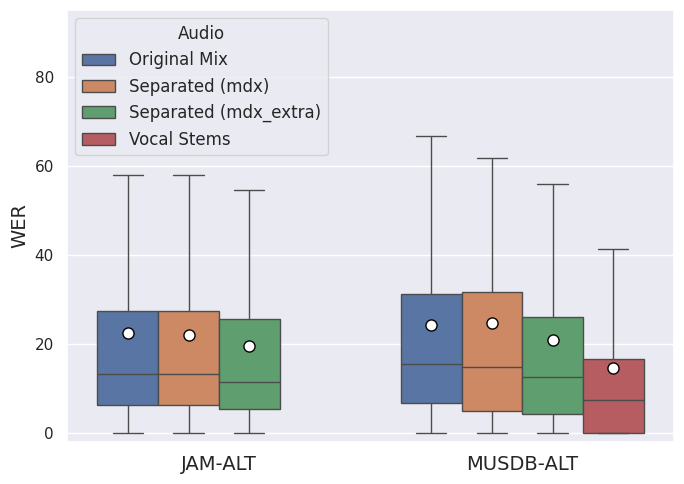

In [7]:
FONTSIZE = 14
fig, ax = plt.subplots(1, 1, figsize=(7, 5), sharey=True)
df = df_samples.query("level == 'verse'").copy()
df["audio"] = pd.Categorical(
    df["audio"].replace(
        {
            "original": "Original Mix",
            "mdx": "Separated (mdx)",
            "mdx_extra": "Separated (mdx_extra)",
            "stem": "Vocal Stems",
        }
    ),
    categories=["Original Mix", "Separated (mdx)", "Separated (mdx_extra)", "Vocal Stems"],
    ordered=True,
)
df["dataset"] = df["dataset"].str.upper()
df["wer"] = df["wer"] * 100
sns.boxplot(
    data=df,
    x="dataset",
    y="wer",
    hue="audio",
    ax=ax,
    showmeans=True,
    showfliers=False,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": "8",
    },
)
ax.get_xaxis().label.set_visible(False)
ax.set_ylabel("WER", fontsize=FONTSIZE)
# ax.set_xlabel("Dataset", fontsize=FONTSIZE-2)
plt.xticks(fontsize=FONTSIZE)
ax.set_ylim(-2,95)
# ax.tick_params(axis="both", which="major", labelsize=FONTSIZE)
plt.legend(loc="upper left", title="Audio",prop={'size':FONTSIZE-2} , title_fontsize=FONTSIZE-2)
plt.tight_layout()
plt.show()
fig.savefig(project_root / "share" / "short_wer_box_2.pdf")